In [ ]:
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    pass


Saving Iris.csv to Iris.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Iris.csv')
df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


##Explore the data
Always check the shape, data types, and whether there are missing values before doing anything else.

In [ ]:
print("Shape:", df.shape)
print()
print(df.info())
print()
print("Missing values per column:")
print(df.isnull().sum())


Shape: (150, 6)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Missing values per column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [ ]:
df['Species'].value_counts()


,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [ ]:
df.describe()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


##Cleaning the data
The `Id` column is just a row number — it has no predictive value, so we drop it before modeling.

In [ ]:
df = df.drop(columns=['Id'])
df.head()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


##Visualize
A pairplot is the single best chart for this dataset — it shows how well each pair of measurements separates the three species.

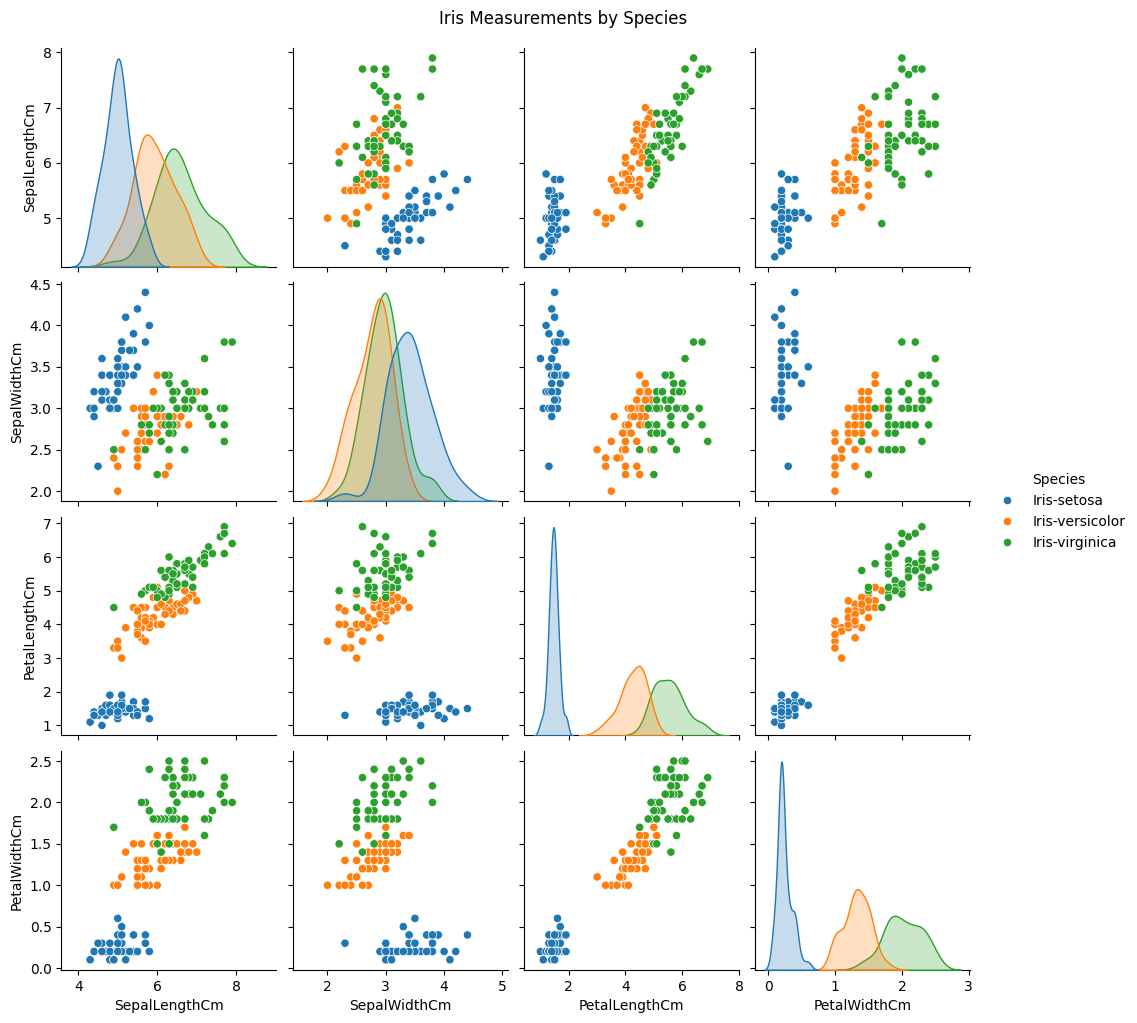

In [ ]:
sns.pairplot(df, hue='Species')
plt.suptitle('Iris Measurements by Species', y=1.02)
plt.show()


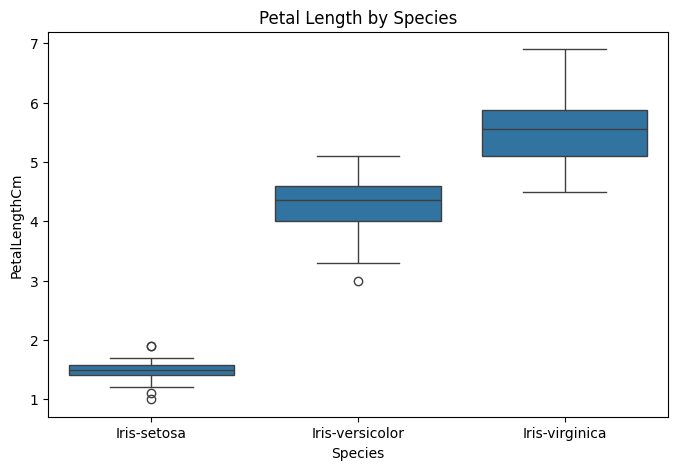

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Species', y='PetalLengthCm', data=df)
plt.title('Petal Length by Species')
plt.show()


**What to look for:** notice how *setosa* is almost perfectly separated from the other two species just by petal length/width. *Versicolor* and *virginica* overlap more, which is where the model will have to work harder.

##Prepare data for modeling
Split the data into features (X = the measurements) and target (y = the species), then into training and test sets.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Species'])
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


Training samples: 120
Test samples: 30


##Train a model
We'll try two simple, beginner-friendly classifiers and compare them: **K-Nearest Neighbors** and **Logistic Regression**.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model 1: K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)

# Model 2: Logistic Regression
logreg = LogisticRegression(max_iter=200)
logreg.fit(X_train, y_train)
logreg_preds = logreg.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_preds))
print("Logistic Regression Accuracy:", accuracy_score(y_test, logreg_preds))


KNN Accuracy: 1.0
Logistic Regression Accuracy: 0.9666666666666667


##Evaluate the best model
Both models are usually close to 95-100% accurate on Iris (it's a well-separated dataset). Let's look closer at one of them with a classification report and confusion matrix.

In [ ]:
print(classification_report(y_test, knn_preds))


                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [ ]:
cm = confusion_matrix(y_test, knn_preds, labels=knn.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — KNN')
plt.show()


##Conclusions

- Petal length and petal width are the strongest predictors of species — far more useful than sepal measurements.
- *Setosa* is perfectly separable from the other two species using petal measurements alone.
- *Versicolor* and *virginica* are the only species the model occasionally confuses, since their petal sizes overlap slightly.
- Both KNN and Logistic Regression achieve high accuracy (typically 95-100%) on this dataset, showing it's a well-structured, linearly separable classification problem.